# Applied Machine Learning - Basic

## Introduction

Organoids are three-dimensional cellular structures that closely resemble the architecture and function of real organs. Grown in vitro from stem cells or other precursor cells, they provide powerful models for investigating organ development, physiology, and pathology, as well as for drug discovery and disease modeling. Their ability to reproduce key aspects of the tissue microenvironment and organ-specific functions makes organoids invaluable tools for exploring disease mechanisms and evaluating potential therapeutic approaches.

Imaging plays a central role in organoid research, as it enables the characterisation of their morphology, growth dynamics, and functional properties. Different features, such as size, shape, and structural complexity, can be extracted and quantitatively analysed to provide meaningful biological information, offering a powerful, non-invasive way to monitor organoid health and behaviour.

In this context, the aim of this work was to evaluate whether organoids belonging to different cancerous and non-cancerous cell lines can be distinguished from brightfield images.

## Dataset

The publicly available Spheroid Light Microscopy Image Atlas (SLIMIA)[1] was used in this study. The dataset comprises approximately 8,000 brightfield images of spheroids derived from both cancerous and non-cancerous cell lines, acquired across different microscopes and formation protocols. To reduce variability related to acquisition conditions and experimental setup, only images obtained with the Axioviert200M microscope and generated using a single seeding density of 2000 cells were selected for this analysis. The resulting subset included 1382 images from 11 different cell lines.

Radiomic features were extracted using the PyRadiomics [2] library. Input images were normalized using z-score scaling, and no additional filters were applied. All feature classes were extracted, resulting in 102 features per organoid image.

## Analysis

In [53]:
import os
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import umap


In [54]:
#Load dataset

#load extracted radiomic features for each cell line
data_path = r"C:\Users\madda\Desktop\SLIMIA\Axiovert200M\Axiovert200M\Axiovert200M_DeWever"
csv_files = glob.glob(os.path.join(data_path, "extracted_features*.csv"))
print(csv_files)

features_dataframe = pd.concat([pd.read_csv(csv) for csv in csv_files], ignore_index = True)

#Get features only dataframe
features = features_dataframe.drop(columns=["Image"])
print("\nFeatures datafame:\n")
print(features.head())

#Get cell line
labels = features_dataframe["Image"].str.split("_").str[0]
print("\nLabels dataframe\n")
print(labels.head())


['C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_4T1.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_A549.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_HCA2hTert.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_HCT116.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_HEPG2.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_MCF7.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_PANC1.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200M\\Axiovert200M_DeWever\\extracted_features_SAR121.csv', 'C:\\Users\\madda\\Desktop\\SLIMIA\\Axiovert200M\\Axiovert200

### Exploratory data analysis (EDA)


In [55]:
print("Number of features:", features.shape[1])

Number of features: 102


In [56]:
print("Number of samples:", features.shape[0])
print("Number of cell lines:", np.unique(labels).shape[0])
print("Cell lines:", np.unique(labels))

Number of samples: 1382
Number of cell lines: 11
Cell lines: ['4T1' 'A549' 'HCA2hTert' 'HCT116' 'HEPG2' 'MCF7' 'PANC1' 'SAR121' 'SKOV3'
 'SW1353' 'U87MG']


Samples distribution per cell line: 
Image
HCT116       270
A549         242
U87MG        152
SKOV3        136
PANC1        135
4T1          116
MCF7          99
SW1353        86
HEPG2         68
SAR121        53
HCA2hTert     25
Name: count, dtype: int64


<Axes: xlabel='Image'>

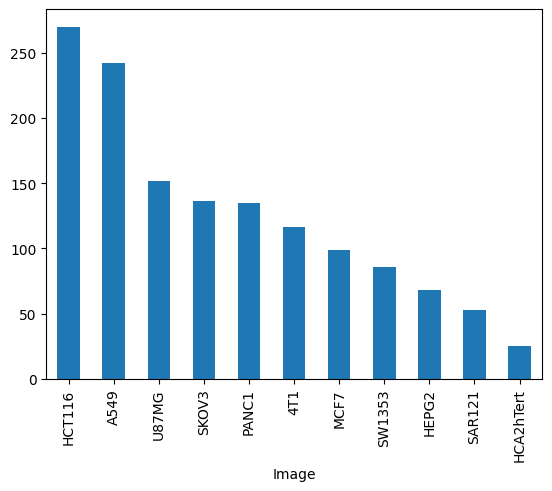

In [57]:
#Dataset distribution per cell line
class_counts = labels.value_counts()
print(f"Samples distribution per cell line: \n{class_counts}")

#plot distribution of classes
class_counts.plot(kind='bar')

One can notice a skewed distribution of samples among classes (largest number of samples = HCT116, lowest number of samples = HCA2hTert)

In [58]:
#Check if there are nans or inf values
features = features.replace([np.inf, -np.inf], np.nan)

if features.isna().any().any():
    print("Features dataframe contains nan values! Please check.")
    exit()


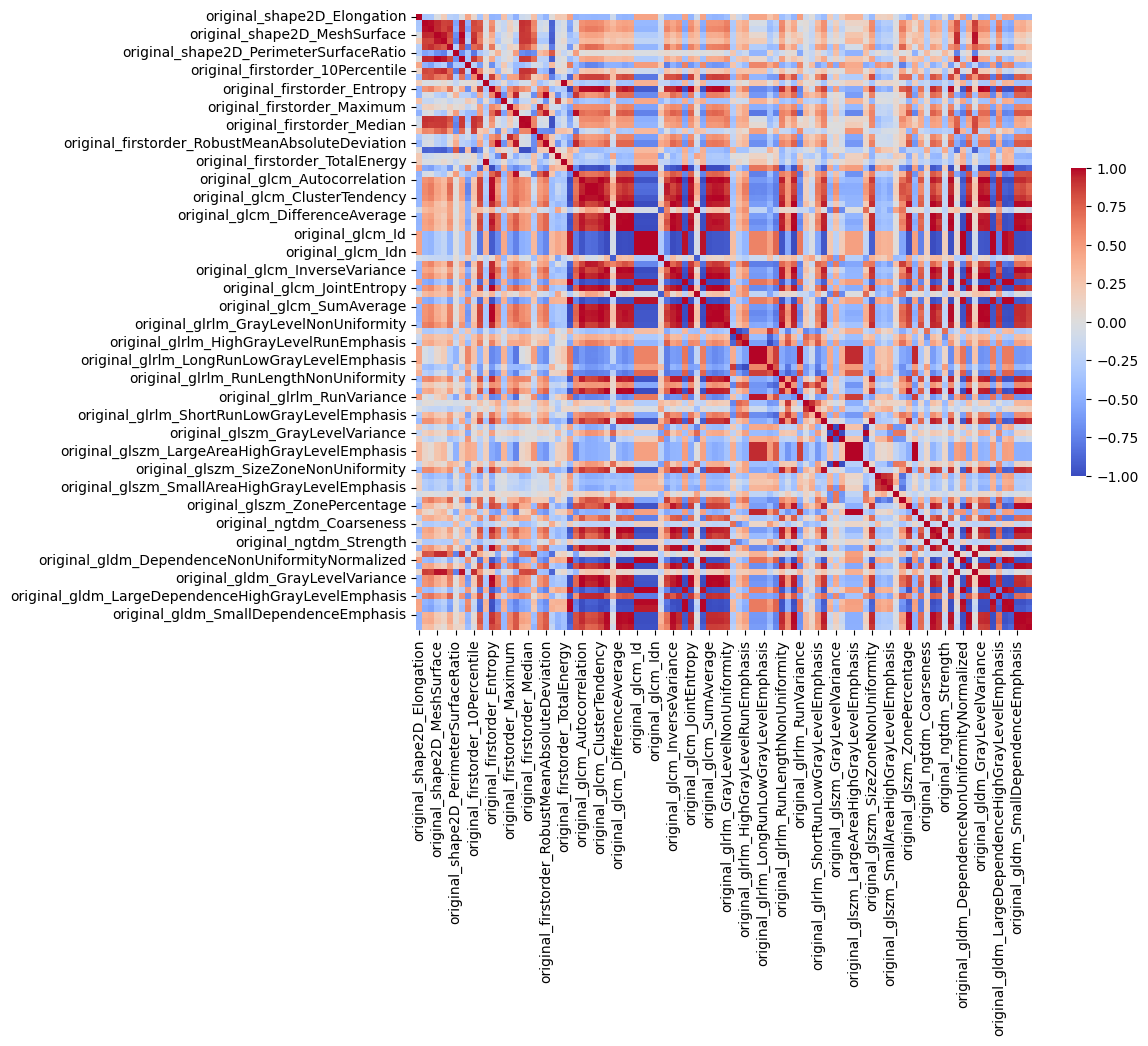

In [59]:
#correlations

corr = features.corr()

#Heatmap correlazioni
f, ax = plt.subplots(figsize = (10,8))
sns.heatmap(corr, cmap="coolwarm", center = 0, vmax=1, vmin = -1, square=True, cbar_kws={"shrink": .5})
plt.show()

The heatmap shows that several radiomic features are highly correlated between themselves.

In [60]:
#Remove highly correlated features
corr_matrix = corr.abs()

#select the upper triangle only
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#select features with correlation >0.95
#Drawback: with this method you have higher chance to exclude higher order features compared to shape and first order features (due to dataframe ordering)
column_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column]>0.95)]

uncorrelated_features = features.drop(columns = column_to_drop)

print(f"Removed {len(column_to_drop)} out of {features.shape[1]} features\n")
print("Removed features:", column_to_drop)
print(f"\nKept features: {uncorrelated_features.columns}")


Removed 62 out of 102 features

Removed features: ['original_shape2D_MaximumDiameter', 'original_shape2D_MinorAxisLength', 'original_shape2D_PixelSurface', 'original_firstorder_Median', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_firstorder_RootMeanSquared', 'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity', 'original_firstorder_Variance', 'original_glcm_Autocorrelation', 'original_glcm_ClusterProminence', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency', 'original_glcm_Contrast', 'original_glcm_DifferenceAverage', 'original_glcm_DifferenceEntropy', 'original_glcm_DifferenceVariance', 'original_glcm_Id', 'original_glcm_Idm', 'original_glcm_Idmn', 'original_glcm_Idn', 'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_JointAverage', 'original_glcm_JointEnergy', 'original_glcm_JointEntropy', 'original_glcm_MCC', 'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy', 'original_glcm_SumS

In [61]:
#Normalisation
#scaler = StandardScaler()
scaler = RobustScaler()

uncorr_features_normalised = scaler.fit_transform(uncorrelated_features)

UMAP is a non-linear dimensionality reduction technique, capable of capturing complex structures and relationships between samples. This method was employed to explore whether the extracted features (uncorrelated and normalised) contained discriminative information between different organoid cell lines.

c:\Users\madda\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\madda\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


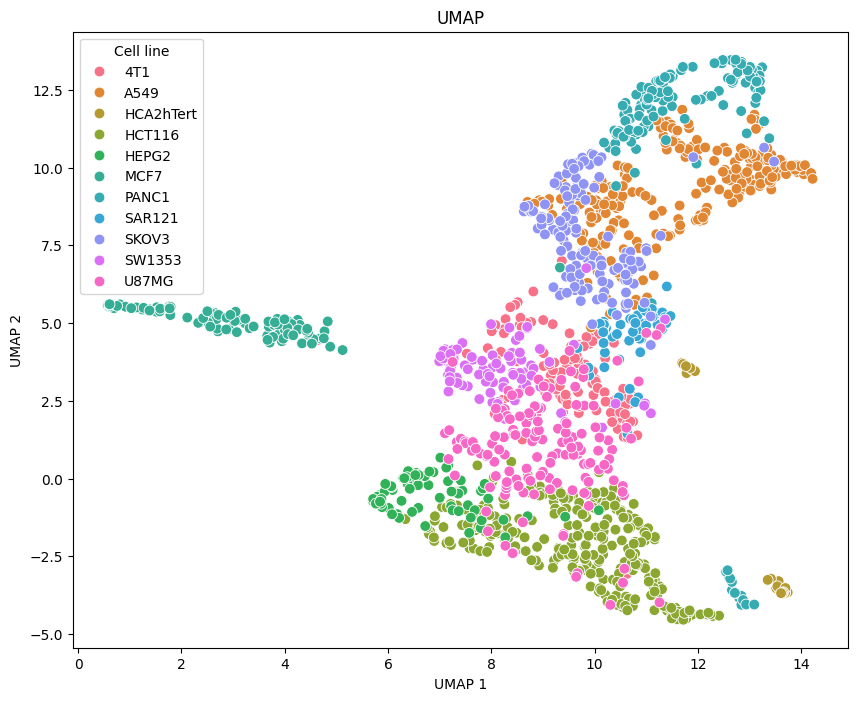

In [62]:
#non-linear data reduction

umap_reducer = umap.UMAP(
    n_neighbors=15,  
    min_dist=0.3,     
    n_components=2,   
    random_state=42)

features_umap = umap_reducer.fit_transform(uncorr_features_normalised)

#Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=features_umap[:, 0],
    y=features_umap[:, 1],
    hue=labels,
    s=60,
)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP")
plt.legend(title="Cell line")
plt.show()



The UMAP plot reveals that some cell lines form distinct clusters (e.g. MCF7), while others show larger overlap with other classes in the feature space (e.g. U87MG).

### Machine Learning

Machine Learning task: multi-class classification

- Class: organoid cell line

- Features for classification: radiomic features extracted from brightfield images

#### Random forest

In [63]:
#Rename features dataframe
X = features.copy()

#Trasformo le labels categoriche in numeriche
le = LabelEncoder()
y = le.fit_transform(labels)

In [64]:
#Train/test split (80%-20%)
RANDOM_STATE = 42
TEST_SIZE = 0.2

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=labels, random_state=RANDOM_STATE) #stratify to keep class distribution proportion between test and train

print(f"Train shape: {x_train.shape}")
print(f"Test_shape: {x_test.shape}")


Train shape: (1105, 102)
Test_shape: (277, 102)


In [65]:
#Pipeline:
# 1. Remove correlated features (class CorrelationFilter)
# 2. Normalise (Robust Scaler)
# 3. Random Forest

#Removing correlated features and normalising after train/test splitting to avoid data leakage


#Class for removing correlated features
class CorrelationFilter(BaseEstimator, TransformerMixin):
    #inherit BaseEstimator and TransformerMixin (for fit transform)
    
    def __init__(self, threshold=0.95):

        #save threshold as attribute
        self.threshold = threshold

    def fit(self, X, y=None):
        """
        Select columns to drop
        """
        
        corr_matrix = X.corr().abs()
        
        #select the upper triangle only
        upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        #create column_to_drop_ attribute
        #select features with correlation >threshold
        #Drawback: with this method you have higher chance to exclude higher order features compared to shape and first order features (due to dataframe ordering)
        self.column_to_drop_ = [column for column in upper_triangle.columns if any(upper_triangle[column]>self.threshold)]

        return self

    def transform(self, X):
        #Remove columns of correlated features
        X_uncorrelated = X.drop(columns=self.column_to_drop_)

        return X_uncorrelated




pipe = Pipeline([("corr_filter", CorrelationFilter(threshold=0.95)), ("scaler", RobustScaler()), ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs= None, class_weight = "balanced"))])
# class_weight to account for unbalanced classes


In [66]:
#hyperparameter space to check
param_dist = {
    "corr_filter__threshold": [0.85, 0.90, 0.95],
    "clf__n_estimators": [200, 400], # number of decision trees in the forest
    "clf__max_depth": [None, 8, 12, 16], #depth of each decision tree
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4], # minimum number of samples per leaf
    "clf__max_features": ["sqrt", "log2", 0.3, 0.5, None],
    "clf__bootstrap": [True, False]
    }


In [67]:
#cross validation

# Stratified to keep class distribution proportion
# shuffle = True because data are ordered per class in the dataframe
# 5 folds
cross_validation = StratifiedKFold(n_splits=5, shuffle = True, random_state=RANDOM_STATE)

In [68]:
random_search = RandomizedSearchCV(
    pipe,
    param_distributions= param_dist,
    n_iter=60, #number of combinations to try
    scoring= "f1_macro", #average F1-score between classes
    n_jobs=-1,
    cv = cross_validation,
    verbose=2,
    random_state=RANDOM_STATE
)

In [69]:
#Fit
print("Starting fitting Random Forest...\n")
start = time.time()

random_search.fit(x_train, y_train) # it searches for best model and fits all training dataset with the best model

end = time.time()
print("Fitting time:", (end-start)/60,  " mins")


Starting fitting Random Forest...

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Fitting time: 6.690287057558695  mins


In [70]:
#extract the best pipeline
best_pipeline = random_search.best_estimator_

corr_filter = best_pipeline.named_steps["corr_filter"]
dropped_columns = corr_filter.column_to_drop_
best_threshold = corr_filter.threshold

print("Best threshold on correlation matrix:\n", best_threshold)
print(f"\nRemoved {len(dropped_columns)} out of 102 features after correlation analysis.\n")

print("Best model params:\n", random_search.best_params_)

print("\nBest score in Cross Validation (F1 macro):\n", random_search.best_score_)


Best threshold on correlation matrix:
 0.9

Removed 77 out of 102 features after correlation analysis.

Best model params:
 {'corr_filter__threshold': 0.9, 'clf__n_estimators': 400, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.3, 'clf__max_depth': 16, 'clf__bootstrap': False}

Best score in Cross Validation (F1 macro):
 0.9179425947077766


In [71]:
#Extract top 10 features used in the classification
#impurity importance: which features improves node purity more 

rf_clf = best_pipeline.named_steps['clf']

importances = rf_clf.feature_importances_

#remove correlated feature columns
x_train_uncorr = x_train.drop(columns=dropped_columns)
features_names_uncorr = x_train_uncorr.columns

importances_df = pd.DataFrame({'Feature': features_names_uncorr, 'Importance': importances}).sort_values(by='Importance', ascending = False)

print("Top 10 features importances \n", importances_df.head(10))


Top 10 features importances 
                                    Feature  Importance
1         original_shape2D_MajorAxisLength    0.108178
2   original_shape2D_PerimeterSurfaceRatio    0.096789
3              original_shape2D_Sphericity    0.078921
10             original_firstorder_Minimum    0.077980
4         original_firstorder_90Percentile    0.077964
7   original_firstorder_InterquartileRange    0.072577
15          original_glrlm_LongRunEmphasis    0.063311
24               original_ngtdm_Coarseness    0.061077
6              original_firstorder_Entropy    0.057954
11            original_firstorder_Skewness    0.051861


Distribution of the 10 most important features for the RF classification per type:
- 3 shape features (MajorAxisLength, PerimeterSurfaceRatio, Sphericity)
- 4 first order features (Minimum, 90Percentile, InterquartileRange, Entropy, Skewness)
- 2 higher order features (LongRunEmphasis, Coarseness)

Even though the processing of data facilitates shape features, 4 first order features and 2 higher order features were found among the most important for classification.

##### Test

In [72]:
# Best model on test set
y_pred = best_pipeline.predict(x_test)

In [73]:
#Classification report
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred,  target_names=le.classes_))


Classification report (test set):
              precision    recall  f1-score   support

         4T1       1.00      0.78      0.88        23
        A549       0.87      0.96      0.91        49
   HCA2hTert       1.00      1.00      1.00         5
      HCT116       0.90      0.98      0.94        54
       HEPG2       1.00      0.79      0.88        14
        MCF7       1.00      0.90      0.95        20
       PANC1       1.00      0.89      0.94        27
      SAR121       0.92      1.00      0.96        11
       SKOV3       0.89      0.89      0.89        27
      SW1353       1.00      1.00      1.00        17
       U87MG       0.78      0.83      0.81        30

    accuracy                           0.91       277
   macro avg       0.94      0.91      0.92       277
weighted avg       0.92      0.91      0.91       277



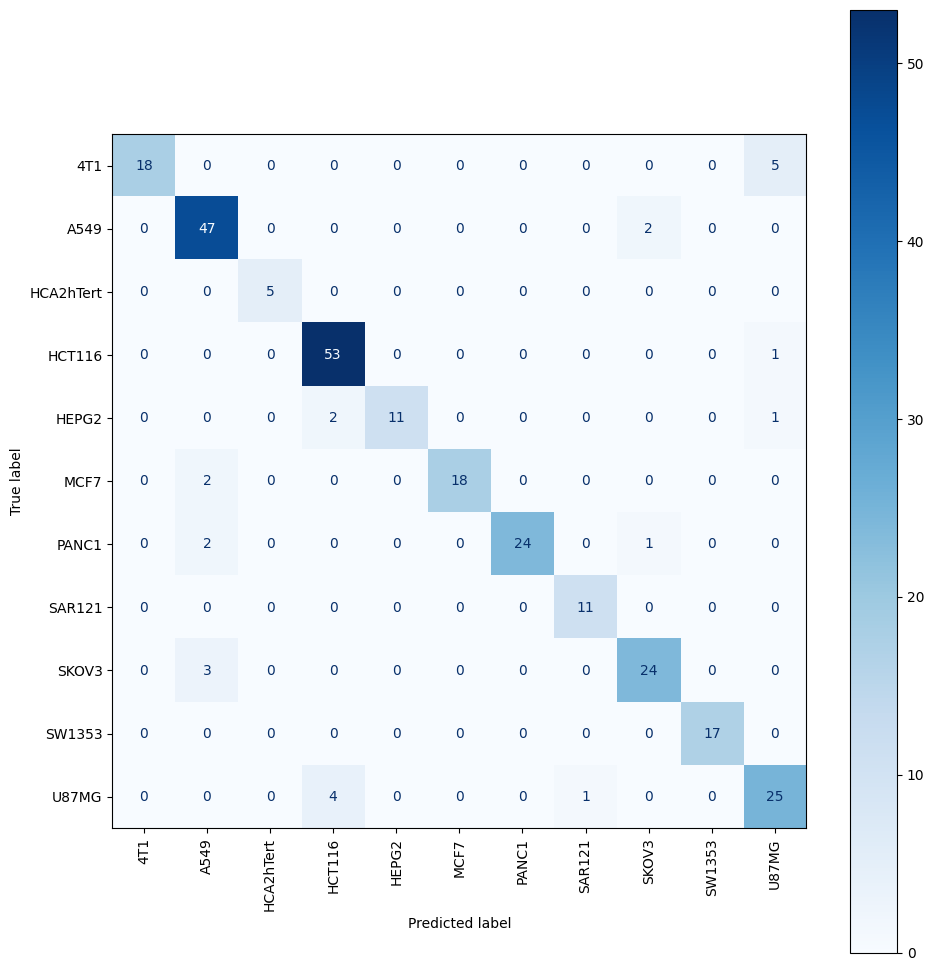

In [74]:
#confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix= conf_matrix, display_labels =le.classes_)
fig, ax = plt.subplots(figsize = (10,10))
disp.plot(ax = ax, xticks_rotation=90, cmap=plt.cm.Blues)
plt.tight_layout()
plt.show()

The Random Forest model exhibits excellent classification performances, with an overall accuracy of 91% and a macro average F1-score of 92%. The model obtained the best classification performances (F1-score = 100%) on HCA2hTert and SW1353 cell lines, even if HCA2Tert has a support of only 5 samples in the test dataset. U87MG cell line had the lowest classification F1-score (81%), mostly driven by an high number of false positives (precision=78%). Indeed, looking at the confusion matrix, one can notice that 5 out of 32 samples predicted as U87MG were misclassified, belonging instead to the 4T1 cell line.

#### Logistic Regression

A logistic regression model was implemented to compare Random Forest performances to a simpler, linear ML model. 


In [75]:
pipe_lr = Pipeline([("corr_filter", CorrelationFilter()), ("scaler", RobustScaler()), ("clf_lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])

In [76]:
#hyperparameter space to check
param_dist_lr = {
    "corr_filter__threshold": [0.85, 0.90, 0.95],
    "clf_lr__C": [0.01, 0.1, 1, 10, 100] #regularization
    }

In [77]:
grid_search_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_dist_lr,
    scoring="f1_macro",
    cv=cross_validation, #same cross validation as Random Forest
    verbose=2,
    n_jobs=-1 
)

In [78]:
#Fit
grid_search_lr.fit(x_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf_lr__C': [0.01, 0.1, ...], 'corr_filter__threshold': [0.85, 0.9, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,threshold,0.95


In [79]:
best_pipeline_lr = grid_search_lr.best_estimator_

corr_filter_lr = best_pipeline_lr.named_steps["corr_filter"]
dropped_columns_lr = corr_filter_lr.column_to_drop_
best_threshold_lr = corr_filter_lr.threshold

print("Best threshold on correlation matrix for Logistic Regression:\n", best_threshold_lr)
print(f"\nRemoved {len(dropped_columns_lr)} out of 102 features after correlation analysis.\n")

print("Best model params:\n", grid_search_lr.best_params_)

print("\nBest score in Cross Validation (F1 macro):\n", grid_search_lr.best_score_)


Best threshold on correlation matrix for Logistic Regression:
 0.95

Removed 63 out of 102 features after correlation analysis.

Best model params:
 {'clf_lr__C': 10, 'corr_filter__threshold': 0.95}

Best score in Cross Validation (F1 macro):
 0.9372709749236285


In [80]:
# Best model on test set
y_pred_lr = best_pipeline_lr.predict(x_test)

In [81]:
#Classification report
print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_lr,  target_names=le.classes_))


Classification report (test set):
              precision    recall  f1-score   support

         4T1       0.88      0.96      0.92        23
        A549       0.98      0.92      0.95        49
   HCA2hTert       1.00      1.00      1.00         5
      HCT116       0.96      0.89      0.92        54
       HEPG2       0.78      1.00      0.88        14
        MCF7       1.00      0.95      0.97        20
       PANC1       1.00      0.93      0.96        27
      SAR121       0.79      1.00      0.88        11
       SKOV3       0.90      0.96      0.93        27
      SW1353       1.00      0.88      0.94        17
       U87MG       0.87      0.90      0.89        30

    accuracy                           0.93       277
   macro avg       0.92      0.94      0.93       277
weighted avg       0.93      0.93      0.93       277



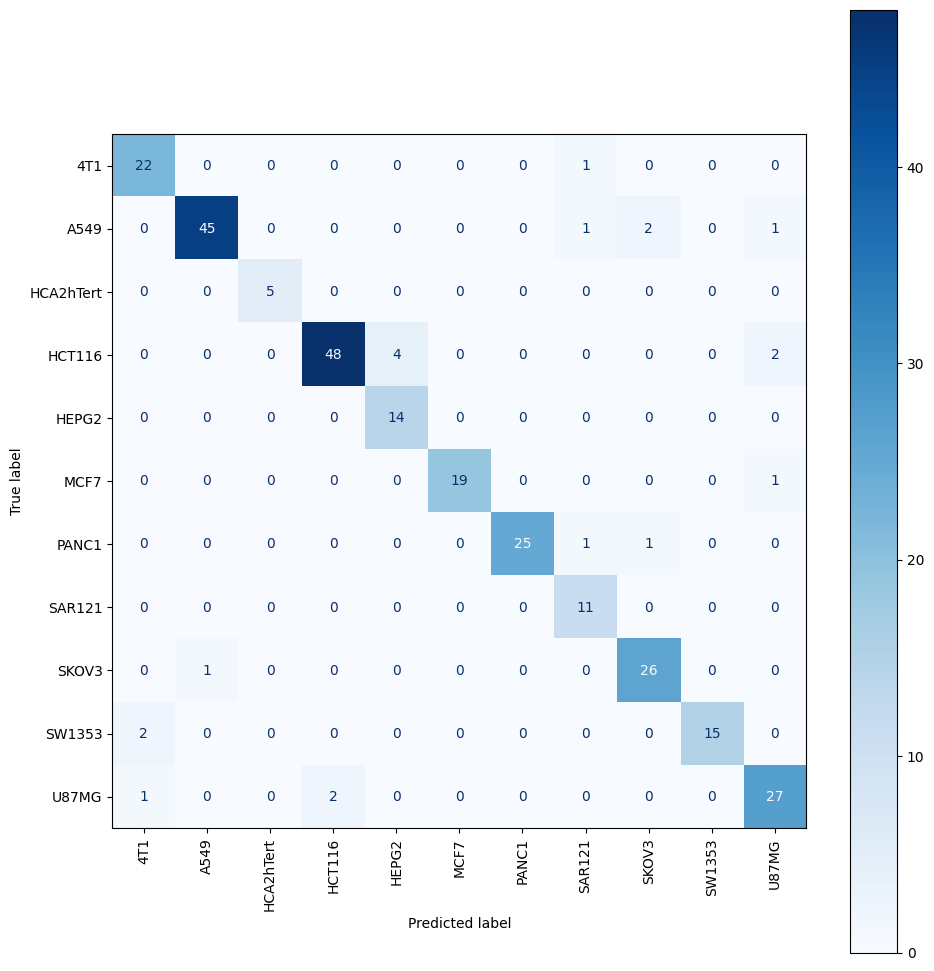

In [82]:
#confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix= conf_matrix_lr, display_labels =le.classes_)
fig, ax = plt.subplots(figsize = (10,10))
disp.plot(ax = ax, xticks_rotation=90, cmap=plt.cm.Blues)
plt.tight_layout()
plt.show()

The logistic regression outperformed the Random Forest model, with an overall accuracy of 93% and a macro average F1-score of 93%. Specifically, it shows improved F1-score for all cell lines but HCT116 and SAR121. F1-score of 100% was found again for the HCA2hTert cell line. Also in this model U87MG cell line shows one of the worst performance, with false positives from A549, HCT116 and MCF7 cell lines.

## References

[1] E. Blondeel, A. Peirsman, S. Vermeulen, and et al. The spheroid light microscopy image atlas for morphometrical analysis of three-dimensional cell cultures. Sci Data, 12(283), 2025.

[2] J. J. M. van Griethuysen, A. Fedorov, C. Parmar, A. Hosny, N. Aucoin, V. Narayan, R. G. H. Beets-Tan, J. C. Fillion-Robin, S. Pieper, and H. J. W. L. Aerts. Computational radiomics system to decode the radiographic
phenotype. Cancer Res, 77(21):e104–e107, 2017.